In [1]:
# ==============================
# Import Libraries
# ==============================
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [2]:
# ==============================
# Load Dataset
# ==============================
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==============================
# Check Missing Values
# ==============================
print("\nMissing Values:")
print(df.isnull().sum())

# ==============================
# Remove Duplicate Rows
# ==============================
df.drop_duplicates(inplace=True)

print("\nShape after removing duplicates:", df.shape)

# ==============================
# Handle Missing Values
# (Median Imputation)
# ==============================
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# ==============================
# Convert Date Features
# ==============================
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# ==============================
# Feature Engineering
# ==============================
df['Delivery_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

# ==============================
# Scale Numerical Features
# ==============================
scaler = StandardScaler()

scaled_cols = ['Production_Units', 'Estimated_Deliveries', 'Avg_Price_USD']

df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

# ==============================
# Final Check
# ==============================
print("\nFinal Missing Values:")
print(df.isnull().sum())

print("\nPreprocessed Data:")
print(df.head())

# ==============================
# 1Save Cleaned Dataset
# ==============================
df.to_csv("tesla_preprocessed.csv", index=False)

print("\nPreprocessing Completed Successfully!")

Dataset Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)       

Dataset Shape: (2640, 14)

First 5 Rows:
     Year  Month         Region    Model  Estimated_Deliveries  \
0  2023.0    5.0         Europe  Model S              1.962744   
1  2015.0    2.0           Asia  Model X             -1.556514   
2  2019.0    1.0  North America  Model X             -0.384021   
3  2021.0    2.0  North America  Model 3             -0.855661   
4  2016.0   12.0    Middle East  Model Y              0.623043   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0          1.705752       0.395982                 120.0     704.0   
1         -1.523982      -1.128346                  75.0     438.0   
2         -0.344347       1.639209                  82.0     480.0   
3         -0.785213       0.218076                 120.0     712.0   
4          0.676360       1.488085                 120.0     661.0   

   CO2_Saved_tons           Source_Type  Charging_Stations        Date  \
0         1863.42  Interpolated (Month)            12207.0  2023-05

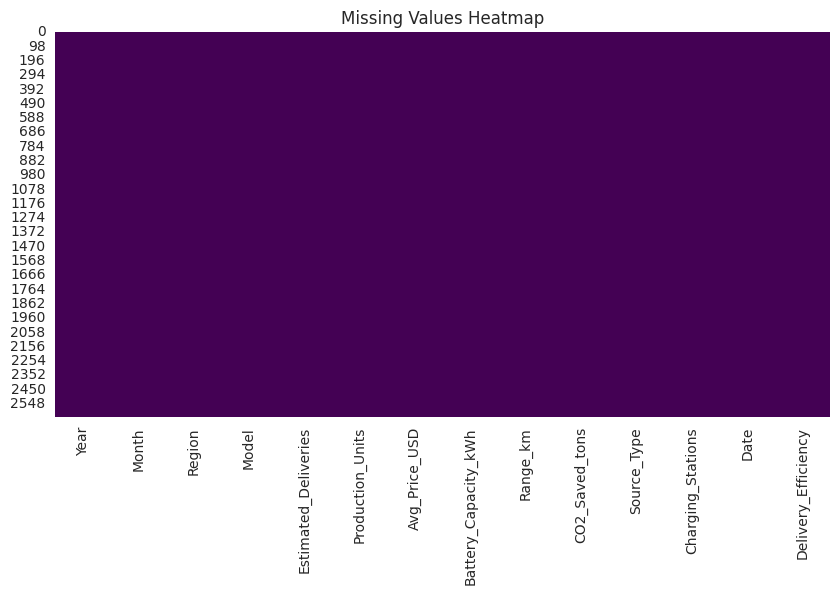

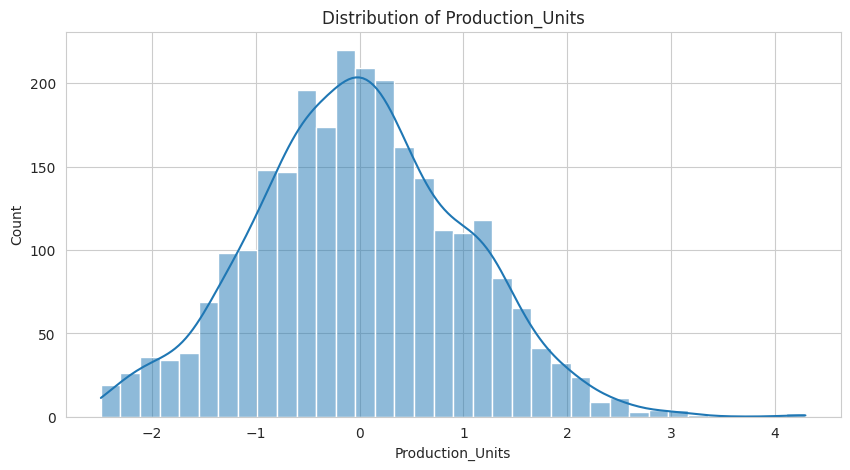

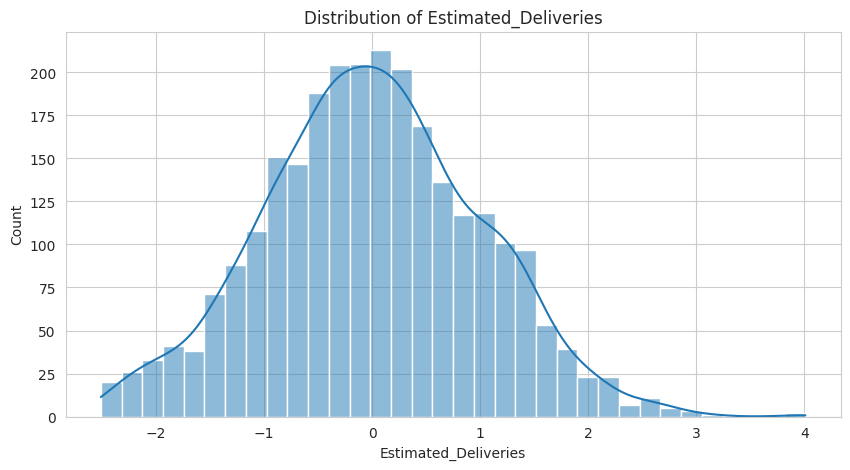

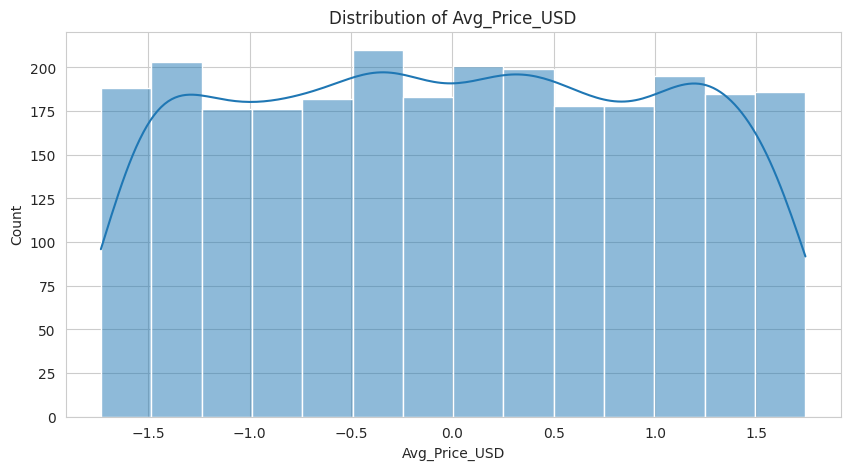

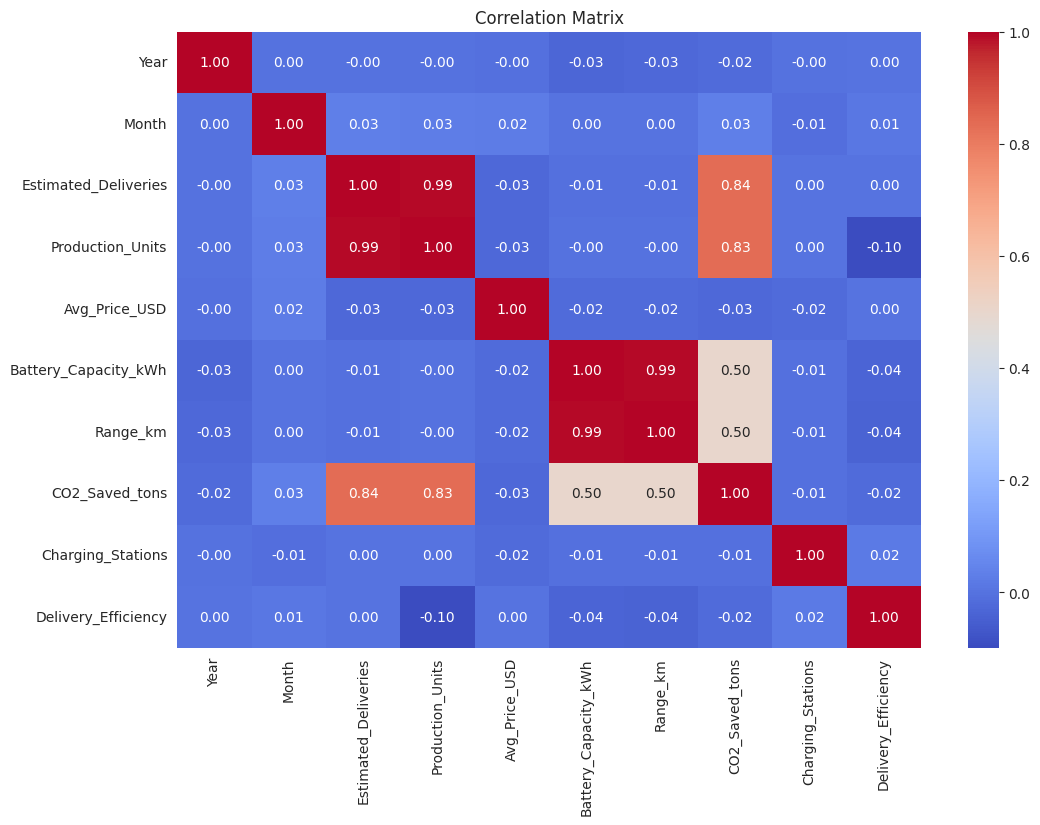

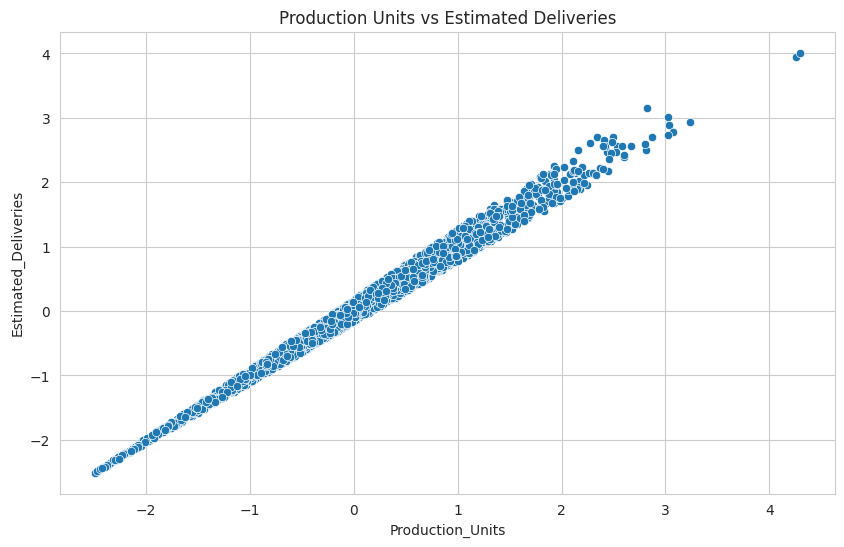

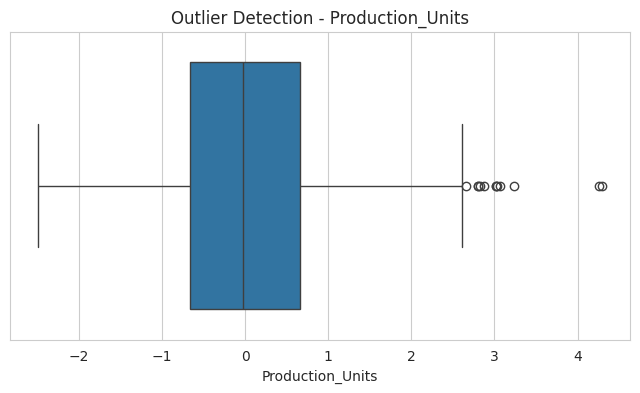

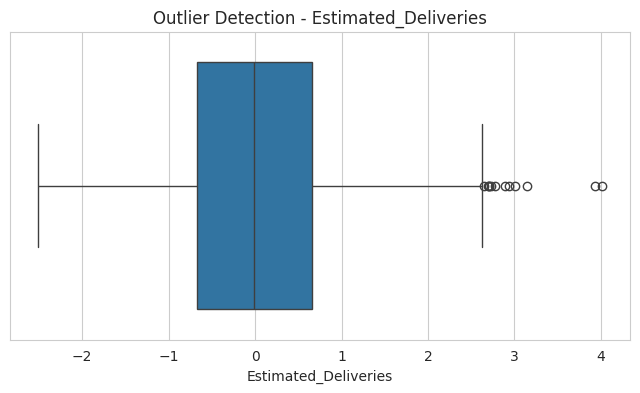

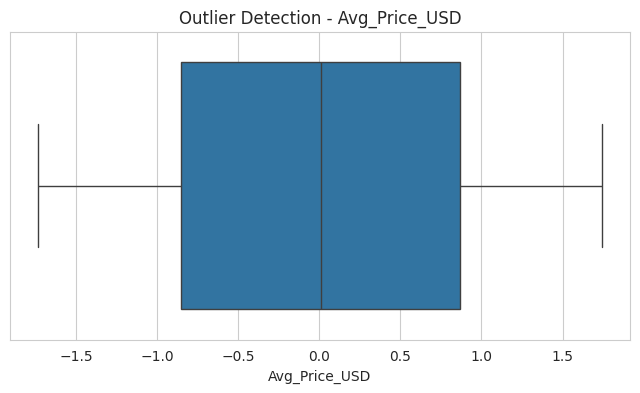

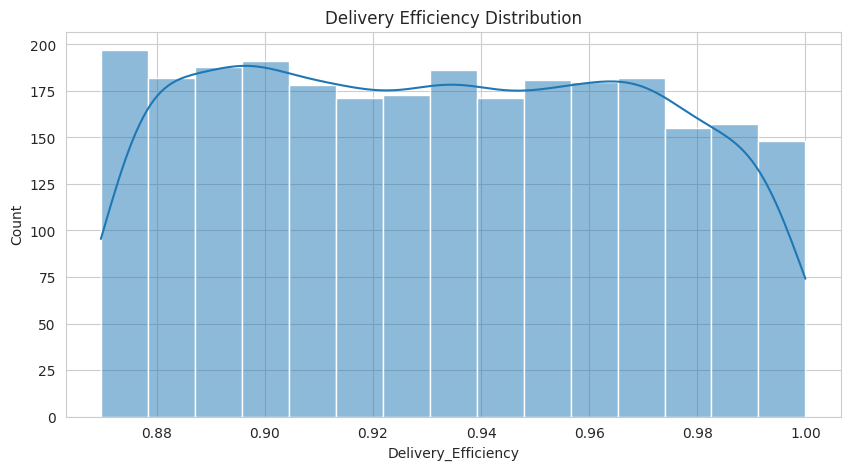

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==============================
# Load Preprocessed Dataset
# ==============================
df = pd.read_csv("tesla_preprocessed.csv")

# ==============================
# Basic Dataset Overview
# ==============================
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# Missing Values Analysis
# ==============================
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# ==============================
# Distribution of Numerical Features
# ==============================
numerical_cols = [
    'Production_Units',
    'Estimated_Deliveries',
    'Avg_Price_USD'
]

for col in numerical_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# ==============================
# Correlation Analysis
# ==============================
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

# ==============================
# Production vs Deliveries
# ==============================
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Production Units vs Estimated Deliveries")
plt.show()

# ==============================
# Boxplots for Outlier Detection
# ==============================
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection - {col}')
    plt.show()

# ==============================
# Delivery Efficiency Analysis
# ==============================
plt.figure(figsize=(10,5))
sns.histplot(df['Delivery_Efficiency'], kde=True)

plt.title("Delivery Efficiency Distribution")
plt.show()

In [4]:
# ==============================
# Feature Engineering
# ==============================


# Load preprocessed dataset
df = pd.read_csv("tesla_preprocessed.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract Quarter
df['Quarter'] = df['Date'].dt.quarter

# Delivery Efficiency
df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

# Production Gap
df['Production_Gap'] = (
    df['Production_Units'] - df['Estimated_Deliveries']
)

# Previous Month Deliveries
df['Previous_Month_Deliveries'] = df['Estimated_Deliveries'].shift(1)
df['Previous_Month_Deliveries'] = df['Previous_Month_Deliveries'].fillna(
    df['Previous_Month_Deliveries'].mean()
)

# Estimated Revenue
df['Estimated_Revenue'] = (
    df['Estimated_Deliveries'] * df['Avg_Price_USD']
)

# Display dataset
print(df.head())

# Save feature engineered dataset
df.to_csv("tesla_feature_engineered.csv", index=False)

print("Feature Engineering Completed Successfully!")

     Year  Month         Region    Model  Estimated_Deliveries  \
0  2023.0    5.0         Europe  Model S              1.962744   
1  2015.0    2.0           Asia  Model X             -1.556514   
2  2019.0    1.0  North America  Model X             -0.384021   
3  2021.0    2.0  North America  Model 3             -0.855661   
4  2016.0   12.0    Middle East  Model Y              0.623043   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0          1.705752       0.395982                 120.0     704.0   
1         -1.523982      -1.128346                  75.0     438.0   
2         -0.344347       1.639209                  82.0     480.0   
3         -0.785213       0.218076                 120.0     712.0   
4          0.676360       1.488085                 120.0     661.0   

   CO2_Saved_tons           Source_Type  Charging_Stations       Date  \
0         1863.42  Interpolated (Month)            12207.0 2023-05-01   
1          249.46    Official (Quart

In [5]:
# ==============================
# Regression Modeling
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load feature engineered dataset
df = pd.read_csv("tesla_feature_engineered.csv")

# ------------------------------
# Define Features and Target
# ------------------------------
X = df.drop(['Estimated_Deliveries', 'Date'], axis=1)
y = df['Estimated_Deliveries']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ------------------------------
# Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# ------------------------------
# Model Training
# ------------------------------
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------
# Predictions
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# Model Evaluation
# ------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


Training Set Shape: (2112, 22)
Testing Set Shape: (528, 22)

Model Performance:
MAE : 0.016281959337935432
RMSE: 0.027428543237849688
R² Score: 0.999218425102642


In [6]:
# ==============================
# Hyperparameter Tuning
# ==============================

from sklearn.model_selection import GridSearchCV

# Load feature engineered dataset
df = pd.read_csv("tesla_feature_engineered.csv")

# ------------------------------
# Define Features and Target
# ------------------------------
X = df.drop(['Estimated_Deliveries', 'Date'], axis=1)
y = df['Estimated_Deliveries']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ------------------------------
# Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------
# Define Parameter Grid
# ------------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# ------------------------------
# Grid Search
# ------------------------------
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# ------------------------------
# Best Parameters
# ------------------------------
print("Best Parameters:")
print(grid_search.best_params_)

# ------------------------------
# Best Model Predictions
# ------------------------------
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

# ------------------------------
# Evaluation
# ------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTuned Model Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Model Performance:
MAE : 0.016308507190590446
RMSE: 0.02771729421057516
R² Score: 0.9992018825962983


Next 12 Months Forecast:
2026-01-01    0.003169
2026-02-01    0.000063
2026-03-01   -0.000008
2026-04-01   -0.000010
2026-05-01   -0.000010
2026-06-01   -0.000010
2026-07-01   -0.000010
2026-08-01   -0.000010
2026-09-01   -0.000010
2026-10-01   -0.000010
2026-11-01   -0.000010
2026-12-01   -0.000010
Freq: MS, Name: predicted_mean, dtype: float64


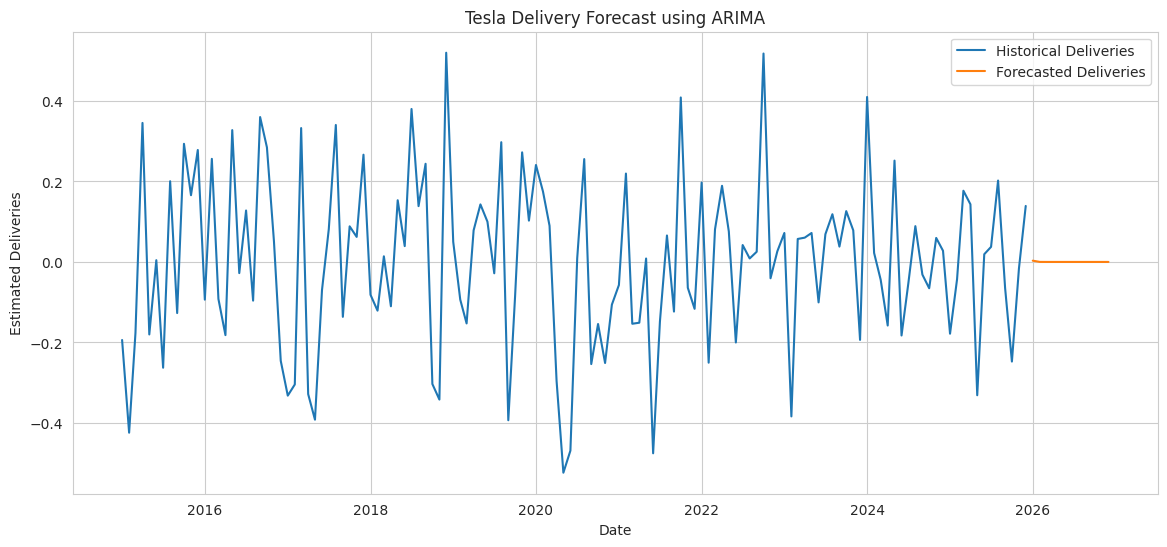

In [7]:
# ==============================
# Time Series Forecasting
# ==============================
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
df = pd.read_csv("tesla_feature_engineered.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Aggregate monthly deliveries
ts = df.groupby('Date')['Estimated_Deliveries'].mean()

# Set monthly frequency
ts = ts.asfreq('MS')

# Fill missing values
ts = ts.ffill()

# Build ARIMA model
model = ARIMA(ts, order=(1,1,1))

# Train model
model_fit = model.fit()

# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

print("Next 12 Months Forecast:")
print(forecast)

# Plot results
plt.figure(figsize=(14,6))

plt.plot(ts, label='Historical Deliveries')
plt.plot(forecast, label='Forecasted Deliveries')

plt.title("Tesla Delivery Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()

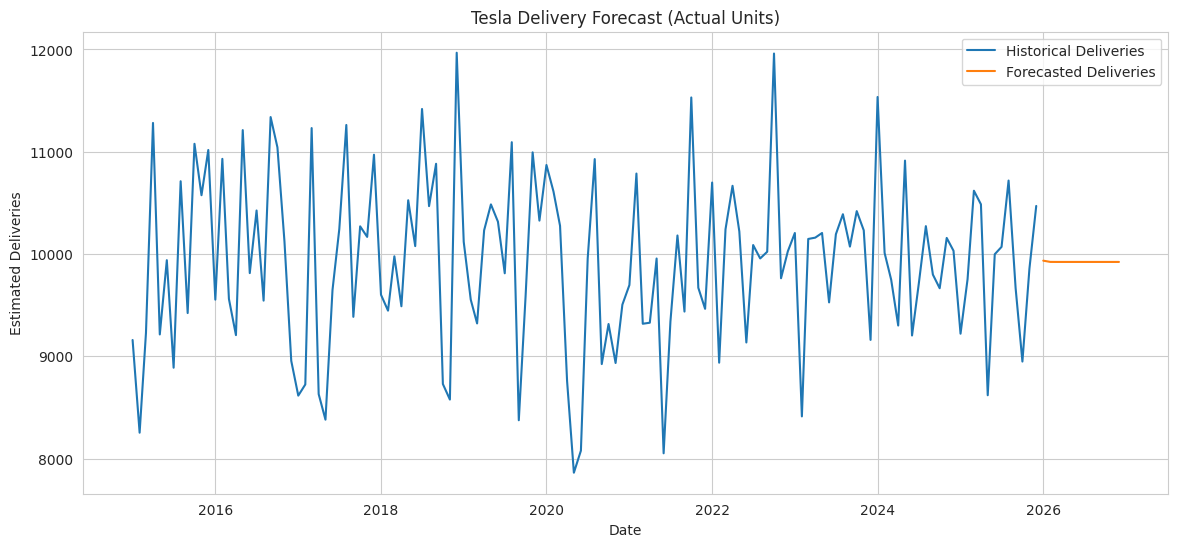

In [8]:
# ==============================
# Inverse Transform
# ==============================

# Load original raw dataset
raw_df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

# Fit scaler on original delivery values
delivery_scaler = StandardScaler()
delivery_scaler.fit(raw_df[['Estimated_Deliveries']])

# Convert scaled historical values back
historical_actual = delivery_scaler.inverse_transform(
    ts.values.reshape(-1, 1)
).flatten()

# Convert forecast back
forecast_actual = delivery_scaler.inverse_transform(
    forecast.values.reshape(-1, 1)
).flatten()

# Plot
plt.figure(figsize=(14,6))

plt.plot(ts.index, historical_actual, label='Historical Deliveries')
plt.plot(forecast.index, forecast_actual, label='Forecasted Deliveries')

plt.title("Tesla Delivery Forecast (Actual Units)")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()